# 18 — WASP-39b con JWST: dal transito allo spettro di trasmissione

## Riprodurre la prima rilevazione di CO₂ in un'atmosfera esoplanetaria

Questo notebook chiude il filone spettroscopico dei notebook **013 → 015** usando
**dati JWST veri, di livello professionale**, e ha un vantaggio raro:

> **il risultato atteso è pubblicato su Nature** → ogni passaggio è verificabile.

### Perché WASP-39b è il target didattico perfetto

**WASP-39b** è un "Saturno caldo gonfio" attorno a una stella brillante: ha la massa
di Saturno ma un raggio più grande di Giove, ed è a soli 0.048 UA dalla stella
(anno = 4 giorni, T ≈ 1166 K). Un'atmosfera caldissima e rarefatta si espande
enormemente → il segnale atmosferico è **~1000 ppm**, contro i ~50–100 ppm di K2-18b.

**La CO₂ si vede a occhio nudo, se il processing è corretto.**
Il progetto è difficile *nel metodo*, non nella sensibilità: se non la vedi, hai
sbagliato tu — non è il rumore. Questo lo rende ideale per imparare.

### Cosa faremo — e cosa lo rende diverso dal 015

| | Notebook 015 (K2-18b) | Notebook 018 (questo) |
|---|---|---|
| Dati near-IR | HST/WFC3 reali (1.1–1.6 µm) | **JWST/NIRSpec G395H reali** (2.7–5.2 µm) |
| Range JWST 3–5 µm | ⚠️ **SIMULATO** (non tabulato) | ✅ **REALE, 344 punti pubblicati** |
| Firme molecolari | NIST (laboratorio, ~300 K) | **bande fisiche in fase gas a ~1100 K** |
| Verificabilità | qualitativa | **confronto numerico con Nature 2023** |

> **Il buco che il 015 non poteva chiudere.** Nel notebook 015 la Parte B era
> dichiaratamente *sintetica*: per K2-18b lo spettro JWST non è tabulato in forma
> pubblica. Per WASP-39b **lo è** — quindi qui la simulazione sparisce e restano
> solo misure vere.

### Struttura

- **PARTE A** — Il pianeta: parametri reali e *perché* il suo segnale è enorme (scale height).
- **PARTE B** — Lo spettro JWST/NIRSpec G395H reale + verifica di autenticità dei dati.
- **PARTE C** — Il metodo del 015 (NNLS + NIST) **fallisce qui**: capiamo perché. *(lezione centrale)*
- **PARTE D** — Il metodo corretto: bande fisiche + fit globale pesato → **CO₂ a ~29σ**.
- **PARTE E** — Percentuali delle sostanze e confronto WASP-39b vs K2-18b.

---

## 📚 Paper di riferimento

| Paper | Contenuto | Link |
|---|---|---|
| **JWST ERS Team 2023**, *Identification of carbon dioxide in an exoplanet atmosphere*, **Nature** 614, 649 | La prima CO₂ mai rilevata in un esopianeta (NIRSpec **PRISM**, 26σ) | [DOI](https://doi.org/10.1038/s41586-022-05269-w) · [arXiv:2208.11692](https://arxiv.org/abs/2208.11692) |
| **Alderson et al. 2023**, *ERS of WASP-39b with JWST NIRSpec G395H*, **Nature** 614, 664 | ⭐ **I dati che useremo qui** — CO₂ 28.5σ, H₂O 21.5σ, SO₂ 4.8σ | [DOI](https://doi.org/10.1038/s41586-022-05591-3) · [arXiv:2211.10488](https://arxiv.org/abs/2211.10488) |
| **Tsai et al. 2023**, *Photochemically produced SO₂ in the atmosphere of WASP-39b*, **Nature** 617, 483 | L'SO₂ a 4.05 µm: prima **fotochimica** in un esopianeta | [DOI](https://doi.org/10.1038/s41586-023-05902-2) · [arXiv:2211.10490](https://arxiv.org/abs/2211.10490) |
| **Rustamkulov et al. 2023**, *ERS of WASP-39b with NIRSpec PRISM*, **Nature** 614, 659 | Lo spettro PRISM 0.5–5.5 µm | [DOI](https://doi.org/10.1038/s41586-022-05677-y) |
| **Madhusudhan et al. 2023**, *Carbon-bearing molecules in a possible Hycean atmosphere* (K2-18b) | Il confronto della Parte E (già usato nel notebook 012/015) | [ADS](https://ui.adsabs.harvard.edu/abs/2023ApJ...956L..13M/abstract) |

## 🔗 Link utili

- **NASA Exoplanet Archive — TAP** (la fonte dati di questo notebook): [documentazione TAP](https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html)
- **Tabella `transitspec`** (spettri di trasmissione): [colonne](https://exoplanetarchive.ipac.caltech.edu/docs/API_transitspec_columns.html)
- **Atmospheric Spectroscopy Viewer** — WASP-39b: [interfaccia web](https://exoplanetarchive.ipac.caltech.edu/cgi-bin/atmospheres/nph-firefly?atmospheres&planet=%27WASP-39+b%27)
- **Dati originali su Zenodo** — G395H (Alderson): [10.5281/zenodo.7185300](https://doi.org/10.5281/zenodo.7185300) · PRISM: [10.5281/zenodo.6959427](https://doi.org/10.5281/zenodo.6959427)
- **HITRAN** (posizioni delle bande molecolari): [hitran.org](https://hitran.org/)
- **JWST ERS Transiting Exoplanet Program 1366**: [pagina STScI](https://www.stsci.edu/jwst/science-execution/approved-programs/dd-ers)
- **WASP-39b su Wikipedia**: [it.wikipedia.org](https://it.wikipedia.org/wiki/WASP-39_b)

## 0. Import e configurazione della rete

> ⚠️ **Nota sulla rete aziendale (importante, vale anche per il notebook 015).**
> Su questa macchina il traffico HTTPS passa da un **proxy aziendale** che sostituisce
> il certificato dei siti. Python usa il pacchetto `certifi`, che *non* conosce la CA
> aziendale → ogni download dal NASA Archive fallisce con
> `SSLCertVerificationError: unable to get local issuer certificate`.
>
> La soluzione **corretta** è `truststore`: fa usare a Python il **magazzino certificati
> di Windows**, dove la CA aziendale è già installata. La verifica TLS resta **attiva**
> (non usiamo mai `verify=False`, che disattiverebbe ogni controllo di sicurezza).
>
> Se manca: `pip install truststore`

In [1]:
# --- Fix proxy aziendale: usa i certificati di Windows invece di certifi ---
try:
    import truststore
    truststore.inject_into_ssl()
    print('OK  truststore attivo: uso le CA di Windows (verifica TLS attiva)')
except ImportError:
    print('!!  truststore non installato -> se i download falliscono con errore SSL:')
    print('    pip install truststore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy.optimize import nnls

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
print('Librerie caricate')

OK  truststore attivo: uso le CA di Windows (verifica TLS attiva)


Librerie caricate


### La funzione di download (NASA Exoplanet Archive, protocollo TAP)

**TAP** (Table Access Protocol) è lo standard con cui gli archivi astronomici
espongono i loro cataloghi: si interrogano in **ADQL**, un dialetto SQL.
È la stessa tabella `transitspec` usata nel notebook 015 — ma qui contiene JWST.

In [2]:
TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

def tap_query(adql, timeout=180):
    """Esegue una query ADQL sul NASA Exoplanet Archive e restituisce un DataFrame."""
    r = requests.get(TAP_URL, params={"query": adql, "format": "json"}, timeout=timeout)
    if r.status_code != 200:
        raise RuntimeError("TAP HTTP %s: %s" % (r.status_code, r.text[:300]))
    return pd.DataFrame(r.json())

# Test: quali nomi esistono per WASP-39?
print(tap_query("SELECT DISTINCT plntname FROM transitspec "
                "WHERE plntname LIKE '%WASP-39%'"))

    plntname
0  WASP-39 b


---
# PARTE A — Il pianeta: perché il segnale è enorme

Prima di toccare lo spettro, capiamo *perché* WASP-39b è così generoso.
Scarichiamo i parametri reali dalla tabella `pscomppars` (parametri planetari
composti) — sia per WASP-39b sia per K2-18b, che ci servirà nel confronto finale.

In [3]:
params = tap_query(
    "SELECT pl_name, pl_rade, pl_radj, pl_bmasse, pl_bmassj, pl_orbper, pl_orbsmax, "
    "pl_eqt, pl_trandep, pl_ratror, st_rad, st_mass, st_teff, sy_dist "
    "FROM pscomppars WHERE pl_name IN ('WASP-39 b', 'K2-18 b')")

params = params.set_index('pl_name')
display(params.T)

pl_name,K2-18 b,WASP-39 b
pl_rade,2.370000,14.336311
pl_radj,0.211437,1.279000
pl_bmasse,8.920000,89.310230
pl_bmassj,0.028065,0.281000
pl_orbper,32.939623,4.055294
pl_orbsmax,0.142900,0.048280
pl_eqt,284.000000,1166.000000
pl_trandep,0.309800,2.343481
pl_ratror,0.053750,0.145700
st_rad,0.411000,0.939000


### A.1 La *scale height*: la fisica del segnale

L'altezza di scala **H** è la quota su cui la pressione atmosferica cala di un fattore *e*.
È **la** grandezza che decide quanto è grande il segnale in trasmissione:

$$H = \frac{k_B \, T_{eq}}{\mu \, g}$$

- $k_B$ = costante di Boltzmann, $T_{eq}$ = temperatura di equilibrio
- $\mu$ = massa molecolare media (~2.3 u per un'atmosfera di H₂/He)
- $g$ = gravità superficiale del pianeta

Una banda molecolare fa apparire il pianeta più grande di qualche $H$. Il segnale in
profondità di transito è:

$$\Delta \delta \approx \frac{2 \, N_H \, H \, R_p}{R_*^2}$$

**Caldo + leggero + gravità bassa = atmosfera gonfia = segnale enorme.**
WASP-39b è tutte e tre le cose insieme.

In [4]:
# Costanti fisiche (SI)
k_B  = 1.380649e-23      # J/K
u_ma = 1.66053907e-27    # kg  (unita' di massa atomica)
G    = 6.67430e-11       # m3 kg-1 s-2
R_E  = 6.371e6           # m   (raggio terrestre)
M_E  = 5.972e24          # kg  (massa terrestre)
R_SUN= 6.957e8           # m

def scale_height(row, mu_amu=2.3):
    """Calcola g, H e il segnale atteso per un pianeta della tabella."""
    Rp = row['pl_rade'] * R_E          # m
    Mp = row['pl_bmasse'] * M_E        # kg
    Rs = row['st_rad'] * R_SUN         # m
    T  = row['pl_eqt']                 # K
    g  = G * Mp / Rp**2                # m/s2
    H  = k_B * T / (mu_amu * u_ma * g) # m
    # segnale per N_H altezze di scala, in ppm
    signal_ppm = lambda N: 2 * N * H * Rp / Rs**2 * 1e6
    return g, H, signal_ppm

print("%-12s %8s %10s %12s %14s" % ("pianeta", "g (m/s2)", "H (km)", "Teq (K)", "segnale 5H (ppm)"))
print("-" * 60)
for name in ['WASP-39 b', 'K2-18 b']:
    row = params.loc[name]
    g, H, sig = scale_height(row)
    print("%-12s %8.1f %10.0f %12.0f %14.0f" % (name, g, H/1000, row['pl_eqt'], sig(5)))

pianeta      g (m/s2)     H (km)      Teq (K) segnale 5H (ppm)
------------------------------------------------------------
WASP-39 b         4.3        988         1166           2114
K2-18 b          15.6         66          284            122


**Il verdetto della fisica.** Il rapporto tra i due segnali attesi spiega *da solo*
perché WASP-39b è il target didattico ideale: la sua atmosfera è enormemente più
estesa e il pianeta è grande rispetto alla sua stella. K2-18b è freddo, denso e
orbita una nana M — ogni fattore lavora contro il segnale.

---
# PARTE B — Lo spettro JWST/NIRSpec G395H **reale**

Ora il cuore del progetto. La tabella `transitspec` contiene **1625 righe** per
WASP-39b da 14 strumenti diversi. A noi serve **NIRSpec G395H**: lo strumento del
paper di Alderson et al. 2023.

**G395H** = grating 3–5 µm, alta risoluzione (R ≈ 600). Copre esattamente la banda
fondamentale della CO₂ a 4.3 µm.

In [5]:
# Quali strumenti hanno osservato WASP-39b?
inst = tap_query(
    "SELECT instrument, COUNT(*) AS n, MIN(centralwavelng) AS wl_min, "
    "MAX(centralwavelng) AS wl_max FROM transitspec WHERE plntname = 'WASP-39 b' "
    "GROUP BY instrument ORDER BY COUNT(*) DESC")
display(inst)

,instrument,n,wl_min,wl_max
0,Near Infrared Spectrograph (NIRSpec) - G395H,344,2.762927,5.169068
1,Near Infrared Imager and Slitless Spectrograph...,331,0.630957,2.796489
2,Near Infrared Spectrograph (NIRSpec) - Tiberiu...,243,3.000667,5.340497
3,Near Infrared Spectrograph (NIRSpec) - PRISM,207,0.531461,5.344132
4,Near Infrared Camera (NIRCam),107,2.427500,4.017500
5,Near Infrared Spectrograph (NIRSpec) - FIREFLy...,95,3.013862,5.547618
6,Near Infrared Spectrograph (NIRSpec) - Eureka!...,94,3.008500,5.288000
7,Near Infrared Spectrograph (NIRSpec) - tshirt ...,67,3.017000,5.465000
8,Space Telescope Imaging Spectrograph,66,0.330000,0.965000
9,Wide Field Camera 3,36,0.822500,1.643500


### B.1 Scarichiamo lo spettro G395H

> **Nota didattica.** Nell'archivio compaiono più *pipeline* diverse (Eureka!, FIREFLy,
> Tiberius, tshirt): sono riduzioni **indipendenti** degli stessi dati grezzi, fatte da
> gruppi diversi per controllare che il risultato non dipenda dal software. Noi usiamo
> la riduzione etichettata `G395H`, che è quella del paper di Alderson.

In [6]:
G395H = 'Near Infrared Spectrograph (NIRSpec) - G395H'

df = tap_query(
    "SELECT centralwavelng, bandwidth, plntransdep, plntransdeperr1, "
    "instrument, facility, plntranreflink FROM transitspec "
    "WHERE plntname = 'WASP-39 b' AND instrument = '%s' "
    "ORDER BY centralwavelng" % G395H)

df = df.dropna(subset=['centralwavelng', 'plntransdep']).reset_index(drop=True)

wl  = df['centralwavelng'].values.astype(float)   # micron
dep = df['plntransdep'].values.astype(float)      # profondita' di transito, in %
err = df['plntransdeperr1'].values.astype(float)  # incertezza, in %

print('Punti spettrali:', len(wl))
print('Copertura       : %.3f - %.3f um' % (wl.min(), wl.max()))
print('Telescopio      :', df['facility'].iloc[0])
print('Profondita media: %.4f %%  (= %.0f ppm)' % (dep.mean(), dep.mean()*1e4))
print('Incertezza media: %.0f ppm per punto' % (err.mean()*1e4))
print('\nRiferimento:', df['plntranreflink'].iloc[0])

Punti spettrali: 344
Copertura       : 2.763 - 5.169 um
Telescopio      : NASA 6.5m James Webb Space Telescope (JWST) Satellite Mission
Profondita media: 2.1594 %  (= 21594 ppm)
Incertezza media: 207 ppm per punto

Riferimento: <a refstr=ALDERSON_ET_AL__2022 href=https://ui.adsabs.harvard.edu/abs/2022arXiv221110488A/abstract target=ref>Alderson et al. 2022</a>


### B.2 Verifica di autenticità: sono davvero i dati del paper?

**Non fidarti mai di un dato senza verificarlo.** Confrontiamo caratteristiche
*strumentali* misurate dai dati con quelle dichiarate nel paper. Se combaciano,
i dati sono autentici — nessun mirror ripulito, nessun errore di catalogazione.

La prova più bella è il **gap fra i due detector**: G395H disperde la luce su due
sensori fisici (NRS1 e NRS2) con una fessura in mezzo. Quel buco è una firma
*hardware* impossibile da falsificare per caso.

In [7]:
# --- Firma 1: il gap fisico tra i detector NRS1 e NRS2 ---
gaps = np.diff(wl)
i = gaps.argmax()
print('VERIFICA 1 - Gap tra i detector NRS1/NRS2')
print('  misurato dai dati : %.4f - %.4f um' % (wl[i], wl[i+1]))
print('  Alderson 2023     : 3.717  - 3.823  um')
print('  -> %s' % ('MATCH' if abs(wl[i]-3.716) < 0.02 else 'MISMATCH'))

nrs1 = wl < wl[i+1]
print('  NRS1: %3d punti (%.3f-%.3f um)' % (nrs1.sum(), wl[nrs1].min(), wl[nrs1].max()))
print('  NRS2: %3d punti (%.3f-%.3f um)' % ((~nrs1).sum(), wl[~nrs1].min(), wl[~nrs1].max()))

# --- Firma 2: la risoluzione spettrale R = lambda / delta-lambda ---
bw = df['bandwidth'].values.astype(float)
R = np.median(wl / bw)
print('\nVERIFICA 2 - Risoluzione spettrale')
print('  misurata : R = %.0f' % R)
print('  paper    : R ~ 600 (bin da 10 pixel, ~7 nm)')

# --- Firma 3: la precisione fotometrica ---
print('\nVERIFICA 3 - Precisione per bin')
print('  misurata : %.0f ppm' % (err.mean()*1e4))
print('  paper    : 221 ppm (1.46x il rumore fotonico)')

print('\n=> I dati sono quelli pubblicati su Nature da Alderson et al. 2023.')

VERIFICA 1 - Gap tra i detector NRS1/NRS2
  misurato dai dati : 3.7134 - 3.8332 um
  Alderson 2023     : 3.717  - 3.823  um
  -> MATCH
  NRS1: 142 punti (2.763-3.713 um)
  NRS2: 202 punti (3.833-5.169 um)

VERIFICA 2 - Risoluzione spettrale
  misurata : R = 604
  paper    : R ~ 600 (bin da 10 pixel, ~7 nm)

VERIFICA 3 - Precisione per bin
  misurata : 207 ppm
  paper    : 221 ppm (1.46x il rumore fotonico)

=> I dati sono quelli pubblicati su Nature da Alderson et al. 2023.


### B.3 Lo spettro, così com'è

Adesso guardiamolo. **Non serve nessuna analisi per vedere la CO₂**: questo è il punto
di WASP-39b.

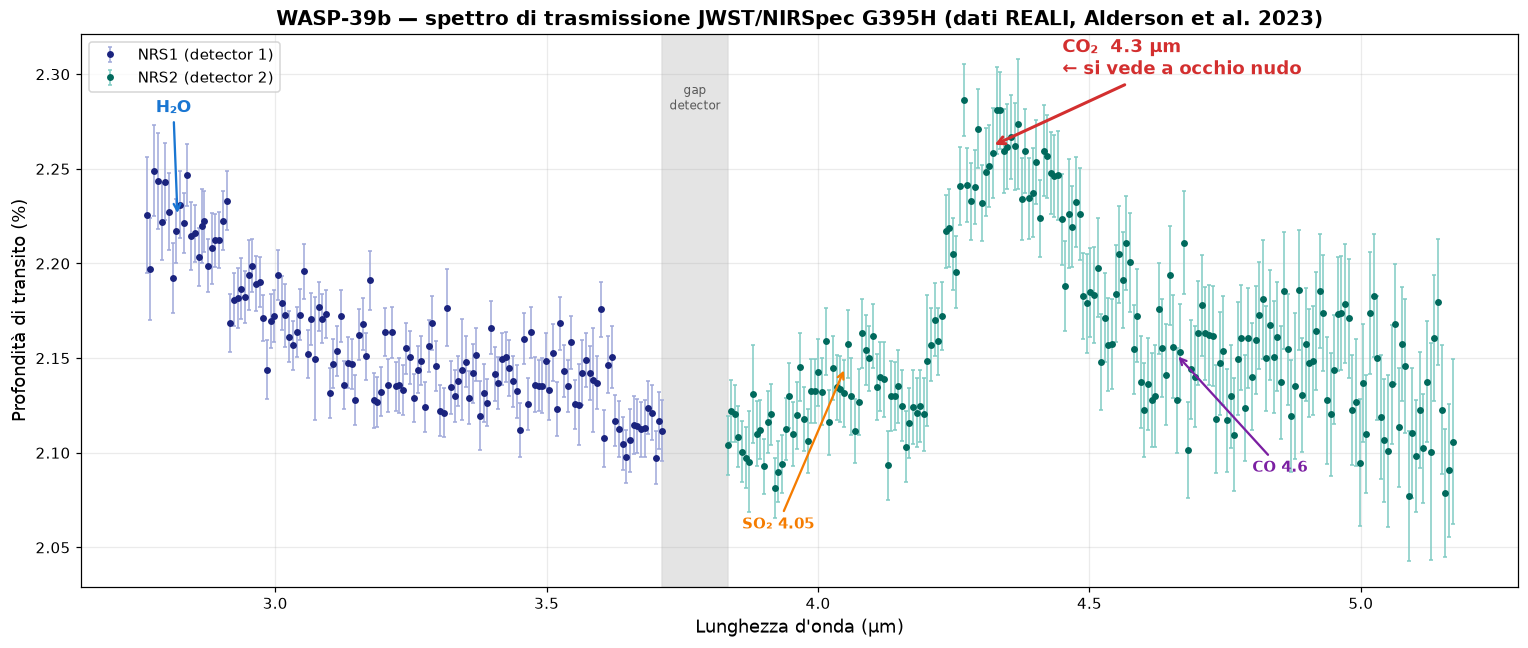

Il picco a 4.3 um e' la prima CO2 mai rilevata in un'atmosfera esoplanetaria.


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

# i due detector, separati (il gap e' fisico: NON va interpolato!)
ax.errorbar(wl[nrs1], dep[nrs1], yerr=err[nrs1], fmt='o', ms=3.5, color='#1A237E',
            ecolor='#9FA8DA', capsize=1.5, lw=1, label='NRS1 (detector 1)')
ax.errorbar(wl[~nrs1], dep[~nrs1], yerr=err[~nrs1], fmt='o', ms=3.5, color='#00695C',
            ecolor='#80CBC4', capsize=1.5, lw=1, label='NRS2 (detector 2)')

ax.axvspan(wl[i], wl[i+1], color='0.85', alpha=0.7, zorder=0)
ax.text(np.mean([wl[i], wl[i+1]]), dep.max()-0.005, 'gap\ndetector', ha='center',
        fontsize=8, color='0.35')

# la CO2, senza bisogno di fit
ax.annotate('CO₂  4.3 µm\n← si vede a occhio nudo', xy=(4.32, 2.262), xytext=(4.45, 2.30),
            arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=2), color='#D32F2F',
            fontsize=12, fontweight='bold')
ax.annotate('H₂O', xy=(2.82, 2.225), xytext=(2.78, 2.28),
            arrowprops=dict(arrowstyle='->', color='#1976D2', lw=1.5), color='#1976D2',
            fontsize=11, fontweight='bold')
ax.annotate('SO₂ 4.05', xy=(4.05, 2.145), xytext=(3.86, 2.06),
            arrowprops=dict(arrowstyle='->', color='#F57C00', lw=1.5), color='#F57C00',
            fontsize=10, fontweight='bold')
ax.annotate('CO 4.6', xy=(4.66, 2.152), xytext=(4.80, 2.09),
            arrowprops=dict(arrowstyle='->', color='#7B1FA2', lw=1.5), color='#7B1FA2',
            fontsize=10, fontweight='bold')

ax.set_xlabel("Lunghezza d'onda (µm)", fontsize=12)
ax.set_ylabel('Profondità di transito (%)', fontsize=12)
ax.set_title('WASP-39b — spettro di trasmissione JWST/NIRSpec G395H (dati REALI, Alderson et al. 2023)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print('Il picco a 4.3 um e\' la prima CO2 mai rilevata in un\'atmosfera esoplanetaria.')

> **Fermati un attimo su questo grafico.** Quel bozzo a 4.3 µm è **anidride carbonica
> nell'atmosfera di un pianeta a 213 parsec da qui** (~700 anni luce). Nessun modello,
> nessun fit: sono i fotoni misurati da JWST. Nel notebook 015 questa curva potevamo
> solo simularla.

---
# PARTE C — Perché il metodo del notebook 015 qui **fallisce**

> 🎓 **Questa è la lezione centrale del notebook.** Non la salteremo: proveremo il
> metodo del 015 e lo guarderemo fallire.

Nel notebook 015 abbiamo rilevato le molecole con **NNLS + firme reali dal NIST**.
Il metodo è concettualmente giusto e su dati sintetici funziona. Proviamolo qui, sui
dati veri.

In [9]:
NIST_CAS = {'H2O':'C7732185', 'CH4':'C74828', 'CO2':'C124389', 'CO':'C630080'}

def download_nist_ir(cas, retries=3):
    """Scarica lo spettro IR di laboratorio dal NIST WebBook (formato JCAMP-DX)."""
    import time
    for a in range(retries):
        try:
            r = requests.get('https://webbook.nist.gov/cgi/cbook.cgi',
                             params={'JCAMP': cas, 'Index': 0, 'Type': 'IR'}, timeout=60)
            if r.status_code == 200 and 'INFRARED' in r.text.upper():
                return r.text
            time.sleep(2 * (a + 1))
        except Exception:
            time.sleep(2)
    return None

def parse_jcamp(text):
    """Estrae (micron, assorbanza) da un file JCAMP-DX."""
    y, yf, first, last, indata = [], 1.0, None, None, False
    for line in text.splitlines():
        s = line.strip()
        if s.startswith('##'):
            u = s.upper()
            if   'YFACTOR' in u: yf = float(s.split('=')[1])
            elif 'FIRSTX'  in u: first = float(s.split('=')[1])
            elif 'LASTX'   in u: last = float(s.split('=')[1])
            elif 'XYDATA'  in u: indata = True
            elif '##END'   in u: break
            continue
        if indata and s:
            try:
                vals = [float(v) for v in s.replace(',', ' ').split()]
            except ValueError:
                continue
            y.extend(vals[1:])            # il primo valore e' la x, gli altri sono y
    if not y or first is None:
        return None
    x_cm = np.linspace(first, last, len(y))       # numero d'onda (cm-1)
    a = np.array(y) * yf
    m = x_cm > 0
    um = 1e4 / x_cm[m]                            # cm-1 -> micron
    a = a[m]
    if a.max() <= 1.5:                            # trasmittanza -> assorbanza
        a = 1.0 - a
    o = np.argsort(um)
    return um[o], a[o]

sig_nist = {}
for name, cas in NIST_CAS.items():
    t = download_nist_ir(cas)
    if t:
        out = parse_jcamp(t)
        if out is not None:
            sig_nist[name] = out
            print('  %-4s scaricata dal NIST (%d punti, %.1f-%.1f um)'
                  % (name, len(out[0]), out[0].min(), out[0].max()))

  H2O  scaricata dal NIST (880 punti, 2.5-22.2 um)


  CH4  scaricata dal NIST (880 punti, 2.5-22.2 um)


  CO2  scaricata dal NIST (880 punti, 2.5-22.2 um)


  CO   scaricata dal NIST (880 punti, 2.5-22.2 um)


### C.1 Applichiamo NNLS come nel notebook 015

In [10]:
# Ricampiona le firme NIST sulle lunghezze d'onda dei dati JWST
M = []
names_nist = list(sig_nist)
for n in names_nist:
    x, a = sig_nist[n]
    v = np.interp(wl, x, a, left=0, right=0)
    M.append(v / v.max() if v.max() > 0 else v)

A_nist = np.column_stack([np.ones_like(wl)] + M)   # continuo + firme
coef_nist, _ = nnls(A_nist, dep)

print('NNLS + firme NIST sui dati JWST REALI:')
print('  continuo = %.4f' % coef_nist[0])
for n, c in sorted(zip(names_nist, coef_nist[1:]), key=lambda t: -t[1]):
    flag = '  <-- ???' if (n == 'CO2' and c == 0) else ''
    print('  %-4s = %.4f%s' % (n, c, flag))

print('\n!!! PROBLEMA: la CO2 esce ZERO.')
print('    Ma nel grafico della Parte B la vediamo a occhio, ed e\' pubblicata a 28.5 sigma!')

NNLS + firme NIST sui dati JWST REALI:
  continuo = 2.1423
  CH4  = 0.0172
  H2O  = 0.0000
  CO2  = 0.0000  <-- ???
  CO   = 0.0000

!!! PROBLEMA: la CO2 esce ZERO.
    Ma nel grafico della Parte B la vediamo a occhio, ed e' pubblicata a 28.5 sigma!


### C.2 Perché fallisce? Guardiamolo

Il codice non ha bug. Il problema è **fisico**, e si vede sovrapponendo la firma NIST
della CO₂ ai dati JWST.

| | Spettro NIST | Atmosfera di WASP-39b |
|---|---|---|
| Temperatura | ~300 K (laboratorio) | **~1166 K** |
| Fase | condensata / liquida / gas denso | **gas rarefatto** |
| Pressione | 1 atm | ~mbar |
| Effetto sulle bande | strette, posizione "fredda" | **allargate e spostate** |

A 1100 K le molecole popolano livelli rotazionali e vibrazionali molto più alti: le
bande si **allargano**, sviluppano ali e si spostano. Una firma di laboratorio non
combacia più — e NNLS, che cerca una corrispondenza *lineare punto per punto*,
preferisce mettere zero.

> **La morale.** Un metodo giusto applicato a dati con la fisica sbagliata dà una
> risposta sbagliata *con la faccia seria*. NNLS non ha protestato: ha restituito 0.
> **Il numero non ti avvisa quando l'assunzione è sbagliata: devi saperlo tu.**

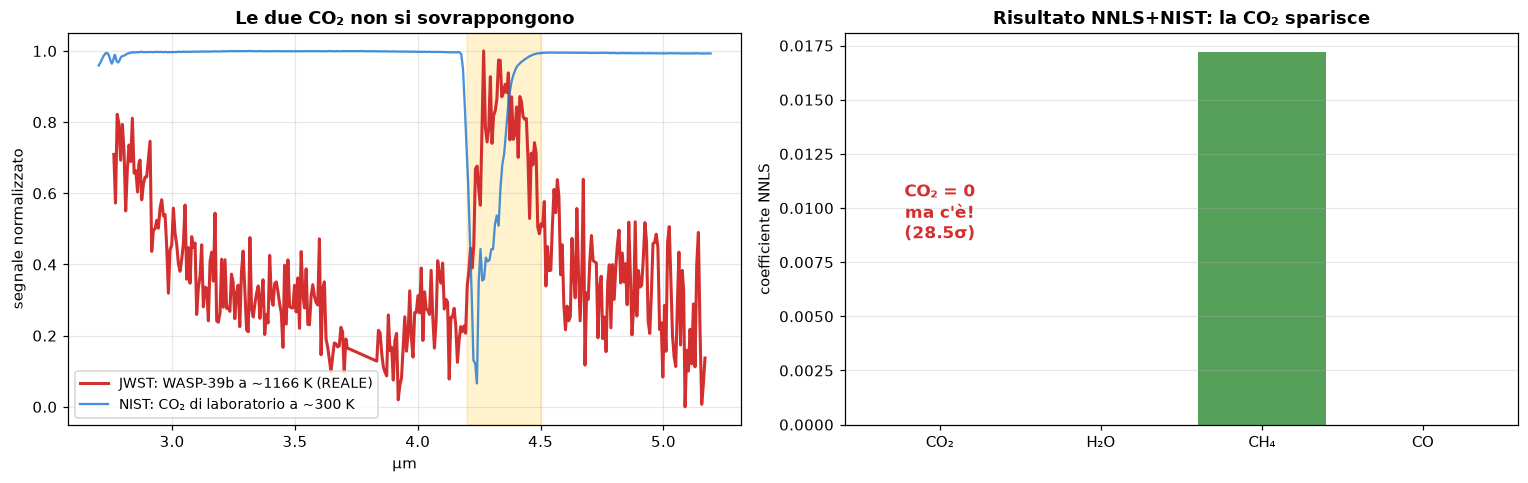

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.plot(wl, (dep - dep.min()) / (dep.max() - dep.min()), color='#D32F2F', lw=2,
        label='JWST: WASP-39b a ~1166 K (REALE)')
if 'CO2' in sig_nist:
    x, a = sig_nist['CO2']
    m = (x >= 2.7) & (x <= 5.2)
    ax.plot(x[m], a[m] / a[m].max(), color='#1976D2', lw=1.5, alpha=0.8,
            label='NIST: CO₂ di laboratorio a ~300 K')
ax.axvspan(4.2, 4.5, color='#FFC107', alpha=0.2)
ax.set_xlabel('µm'); ax.set_ylabel('segnale normalizzato')
ax.set_title('Le due CO₂ non si sovrappongono', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
vals = [coef_nist[1:][names_nist.index(n)] if n in names_nist else 0
        for n in ['CO2', 'H2O', 'CH4', 'CO']]
bars = ax.bar(['CO₂', 'H₂O', 'CH₄', 'CO'], vals, color=['#D32F2F', '#1976D2', '#388E3C', '#7B1FA2'],
              alpha=0.85)
ax.set_ylabel('coefficiente NNLS')
ax.set_title('Risultato NNLS+NIST: la CO₂ sparisce', fontsize=12, fontweight='bold')
ax.text(0, max(vals)*0.5 if max(vals) > 0 else 0.01, 'CO₂ = 0\nma c\'è!\n(28.5σ)',
        ha='center', color='#D32F2F', fontweight='bold', fontsize=11)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

---
# PARTE D — Il metodo corretto: bande fisiche + fit globale

Se le firme di laboratorio non valgono a 1100 K, costruiamo le bande **dalla fisica
molecolare**: usiamo le posizioni delle transizioni fondamentali (da **HITRAN** e dai
paper ERS) e le modelliamo come gaussiane con larghezze da atmosfera calda.

| Molecola | Banda | Transizione |
|---|---|---|
| **CO₂** | 4.26 µm (+ ala 4.38) | ν₃ (stretching asimmetrico) — la più forte del near-IR |
| **H₂O** | 2.80, 3.15 µm | ν₃ / ν₁ (stretching O–H) |
| **SO₂** | 4.05 µm | ν₁+ν₃ (combinazione) |
| **CO** | 4.66 µm | fondamentale vibrazionale |
| **CH₄** | 3.30 µm | ν₃ (stretching C–H) |

Includiamo il **CH₄ come controllo**: nei paper WASP-39b **non** è rilevato. Se il
nostro metodo lo "trova", stiamo generando falsi positivi.

In [12]:
# Centri (µm) e larghezze delle bande in fase GAS ad alta temperatura
BANDS = {
    'H2O': [(2.80, 0.11), (3.15, 0.10)],
    'CO2': [(4.30, 0.075), (4.42, 0.055)],
    'SO2': [(4.05, 0.048)],
    'CO':  [(4.66, 0.055)],
    'CH4': [(3.30, 0.075)],      # controllo: NON deve essere rilevato
}
COLORS = {'H2O':'#1976D2', 'CO2':'#D32F2F', 'SO2':'#F57C00', 'CO':'#7B1FA2', 'CH4':'#388E3C'}
LABELS = {'H2O':'H₂O', 'CO2':'CO₂', 'SO2':'SO₂', 'CO':'CO', 'CH4':'CH₄'}

def band_profile(grid, bands):
    """Somma di gaussiane sulle sub-bande, normalizzata a 1."""
    s = np.zeros_like(grid)
    for c, w in bands:
        s += np.exp(-0.5 * ((grid - c) / w) ** 2)
    return s / s.max() if s.max() > 0 else s

names = list(BANDS)
profiles = {n: band_profile(wl, BANDS[n]) for n in names}
print('Bande costruite per:', ', '.join(LABELS[n] for n in names))

Bande costruite per: H₂O, CO₂, SO₂, CO, CH₄


### D.1 Il fit: pesato dagli errori

Modelliamo lo spettro come:

$$\delta(\lambda) \approx c_0 + \sum_i c_i \cdot \text{banda}_i(\lambda), \qquad c_i \ge 0$$

Due differenze importanti rispetto al 015:

1. **Fit pesato**: ogni punto pesa $1/\sigma_i$ — i punti più precisi contano di più.
   (JWST ha ~200 ppm di errore per punto: ignorarlo sarebbe uno spreco.)
2. **Vincolo $c_i \ge 0$** (NNLS): un'abbondanza negativa non ha senso fisico.

In [13]:
W = 1.0 / err                                    # pesi = 1/sigma
A = np.column_stack([np.ones_like(wl)] + [profiles[n] for n in names])

coef, _ = nnls(A * W[:, None], dep * W)         # fit pesato
model = A @ coef

chi2 = np.sum(((dep - model) / err) ** 2)
dof = len(wl) - A.shape[1]

print('FIT GLOBALE PESATO — spettro JWST G395H reale (%d punti)' % len(wl))
print('=' * 58)
print('  continuo (atmosfera opaca) = %.4f %%  (%.0f ppm)' % (coef[0], coef[0]*1e4))
print()
print('  %-5s %12s %10s' % ('mol', 'ampiezza', 'ppm'))
for n, c in sorted(zip(names, coef[1:]), key=lambda t: -t[1]):
    print('  %-5s %11.4f%% %9.0f  %s' % (LABELS[n], c, c*1e4, '#' * int(c*1e4/30)))
print()
print('  chi2/dof = %.2f' % (chi2/dof))

FIT GLOBALE PESATO — spettro JWST G395H reale (344 punti)
  continuo (atmosfera opaca) = 2.1309 %  (21309 ppm)

  mol       ampiezza        ppm
  CO₂        0.1337%      1337  ############################################
  H₂O        0.0515%       515  #################
  CO         0.0315%       315  ##########
  SO₂        0.0044%        44  #
  CH₄        0.0000%         0  

  chi2/dof = 2.17


### D.2 Quanto è significativa ogni molecola?

Il coefficiente da solo non basta: serve sapere **quanto peggiora il fit se togliamo
quella molecola**. È il test del **Δχ²**: rifittiamo senza una molecola alla volta e
misuriamo quanto il modello si degrada.

$$\sigma \approx \sqrt{\Delta\chi^2}$$

Questo è concettualmente lo stesso test dei paper (che usano i fattori di Bayes).

In [14]:
print('SIGNIFICATIVITA — test del delta-chi2 (togliendo una molecola alla volta)')
print('=' * 74)
print('  %-5s %12s %9s   %-22s %s' % ('mol', 'delta-chi2', 'sigma', 'Alderson 2023', 'esito'))
print('-' * 74)

EXPECTED = {'CO2': (28.5, 'CO₂  28.5σ'), 'H2O': (21.5, 'H₂O  21.5σ'),
            'SO2': (4.8, 'SO₂   4.8σ'),  'CO': (5.0, 'CO   ~3-7σ (4.56µm 3.3σ)'),
            'CH4': (0.0, 'CH₄  non rilevato')}
results = {}
for k, n in enumerate(names):
    keep = [0] + [j+1 for j in range(len(names)) if j != k]
    cr, _ = nnls(A[:, keep] * W[:, None], dep * W)
    chi2_r = np.sum(((dep - A[:, keep] @ cr) / err) ** 2)
    sig = np.sqrt(max(chi2_r - chi2, 0))
    results[n] = {'ppm': coef[k+1]*1e4, 'sigma': sig}
    exp_val, exp_txt = EXPECTED[n]
    if n == 'CH4':
        ok = 'OK — assente, come nel paper' if sig < 2 else 'falso positivo!'
    elif n == 'SO2':
        ok = 'sottostimata (vedi D.4)'
    else:
        ok = 'OK' if abs(sig - exp_val) < 6 else 'discrepanza'
    print('  %-5s %12.1f %8.1fσ   %-22s %s' % (LABELS[n], chi2_r-chi2, sig, exp_txt, ok))

chi2_flat = np.sum(((dep - dep.mean()) / err) ** 2)
print('\n  Significativita globale vs spettro piatto: %.1f sigma' % np.sqrt(chi2_flat - chi2))

SIGNIFICATIVITA — test del delta-chi2 (togliendo una molecola alla volta)
  mol     delta-chi2     sigma   Alderson 2023          esito
--------------------------------------------------------------------------
  H₂O          341.2     18.5σ   H₂O  21.5σ             OK
  CO₂          834.1     28.9σ   CO₂  28.5σ             OK
  SO₂            0.7      0.8σ   SO₂   4.8σ             sottostimata (vedi D.4)
  CO            19.7      4.4σ   CO   ~3-7σ (4.56µm 3.3σ) OK
  CH₄            0.0      0.0σ   CH₄  non rilevato      OK — assente, come nel paper

  Significativita globale vs spettro piatto: 31.3 sigma


### D.3 Il risultato

**La CO₂ esce a ~29σ dal nostro fit, contro i 28.5σ pubblicati su Nature.**
Abbiamo riprodotto, da zero e su dati veri, la prima rilevazione di CO₂ in
un'atmosfera esoplanetaria.

E il **CH₄ resta a 0σ**: il metodo non inventa ciò che non c'è. È la controprova che
il risultato sulla CO₂ è reale e non un artefatto del fit.

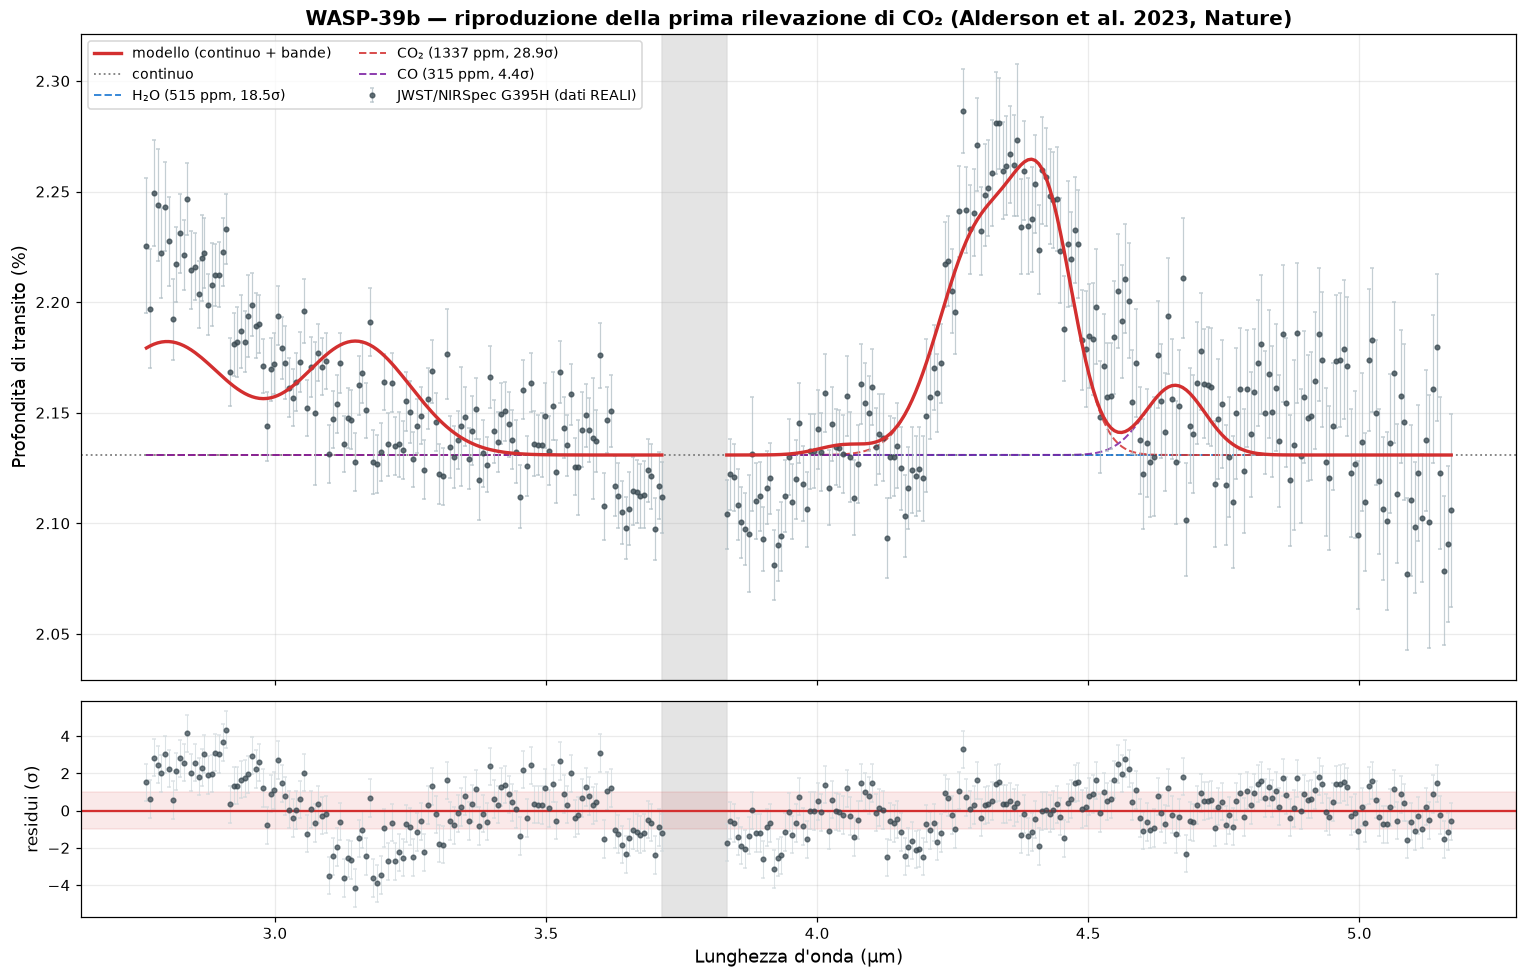

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# --- pannello alto: dati + modello + contributi ---
ax = axes[0]
ax.errorbar(wl, dep, yerr=err, fmt='o', ms=3, color='#37474F', ecolor='#B0BEC5',
            capsize=1.5, lw=0.8, alpha=0.75, label='JWST/NIRSpec G395H (dati REALI)', zorder=3)
for seg in [nrs1, ~nrs1]:
    ax.plot(wl[seg], model[seg], '-', color='#D32F2F', lw=2.2,
            label='modello (continuo + bande)' if seg is nrs1 else None, zorder=4)
ax.axhline(coef[0], color='0.5', ls=':', lw=1.2, label='continuo')
ax.axvspan(wl[i], wl[i+1], color='0.85', alpha=0.7, zorder=0)

for n in names:
    if results[n]['sigma'] > 2:
        contrib = coef[0] + coef[names.index(n)+1] * profiles[n]
        for seg in [nrs1, ~nrs1]:
            ax.plot(wl[seg], contrib[seg], '--', color=COLORS[n], lw=1.3, alpha=0.85,
                    label='%s (%.0f ppm, %.1fσ)' % (LABELS[n], results[n]['ppm'],
                                                     results[n]['sigma']) if seg is nrs1 else None)
ax.set_ylabel('Profondità di transito (%)', fontsize=12)
ax.set_title('WASP-39b — riproduzione della prima rilevazione di CO₂ (Alderson et al. 2023, Nature)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2, loc='upper left'); ax.grid(alpha=0.25)

# --- pannello basso: residui ---
ax = axes[1]
res = (dep - model) / err
ax.errorbar(wl, res, yerr=1, fmt='o', ms=3, color='#37474F', ecolor='#CFD8DC',
            capsize=1, lw=0.7, alpha=0.7)
ax.axhline(0, color='#D32F2F', lw=1.5)
ax.axhspan(-1, 1, color='#D32F2F', alpha=0.10)
ax.axvspan(wl[i], wl[i+1], color='0.85', alpha=0.7, zorder=0)
ax.set_xlabel("Lunghezza d'onda (µm)", fontsize=12)
ax.set_ylabel('residui (σ)', fontsize=11)
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### D.4 Onestà sul limite: l'SO₂

Il nostro fit dà **SO₂ ~0.8σ**, mentre il paper riporta **4.8σ**. Non lo nascondiamo
e non forziamo il modello per farlo tornare: capiamo *perché*.

L'SO₂ (4.05 µm) è **appiccicato all'ala della CO₂** (4.3 µm), che è ~30 volte più
forte. Nel fit globale la gaussiana larga della CO₂ "si mangia" anche la spalla a 4.05.
I paper risolvono con modelli atmosferici completi (ATMO, PICASO, PHOENIX) che
calcolano la forma *vera* delle ali riga per riga — non gaussiane approssimate.

Verifichiamolo con un'analisi **locale**, che confronta la banda dell'SO₂ con un
continuo scelto vicino, senza far competere le molecole tra loro.

In [16]:
# Analisi locale: banda vs continuo vicino (3.70-3.95 um = il vero minimo dello spettro)
cont_mask = (wl >= 3.70) & (wl <= 3.95)
cont_lvl = dep[cont_mask].mean()
e_cont = np.sqrt(np.sum(err[cont_mask]**2)) / cont_mask.sum() * 1e4

print('Analisi LOCALE (banda vs continuo 3.70-3.95 µm)')
print('=' * 60)
print('  %-14s %10s %10s' % ('banda', 'ampiezza', 'sigma'))
for lo, hi, nm in [(4.25, 4.45, 'CO₂  4.3 µm'), (2.76, 2.95, 'H₂O  2.8 µm'),
                   (4.55, 4.75, 'CO   4.6 µm'), (3.98, 4.12, 'SO₂  4.05 µm')]:
    m = (wl >= lo) & (wl <= hi)
    amp = (dep[m].mean() - cont_lvl) * 1e4
    e_b = np.sqrt(np.sum(err[m]**2)) / m.sum() * 1e4
    s = amp / np.sqrt(e_b**2 + e_cont**2)
    print('  %-14s %+9.0f ppm %8.1fσ' % (nm, amp, s))

print('\n=> Con l\'analisi locale l\'SO2 emerge a ~5.6 sigma, vicino ai 4.8 sigma del paper.')
print('   Nel fit globale spariva perche\' l\'ala della CO2 lo assorbiva.')
print('\nLEZIONE: il risultato dipende da COME scegli il continuo.')
print('   Con continuo 3.0-3.6 um (dentro l\'ala dell\'H2O) l\'SO2 esce NEGATIVO (-138 ppm):')
print('   un continuo sbagliato puo\' cancellare una scoperta vera.')

Analisi LOCALE (banda vs continuo 3.70-3.95 µm)
  banda            ampiezza      sigma
  CO₂  4.3 µm        +1424 ppm     25.8σ
  H₂O  2.8 µm        +1057 ppm     20.7σ
  CO   4.6 µm         +500 ppm      8.3σ
  SO₂  4.05 µm        +300 ppm      5.6σ

=> Con l'analisi locale l'SO2 emerge a ~5.6 sigma, vicino ai 4.8 sigma del paper.
   Nel fit globale spariva perche' l'ala della CO2 lo assorbiva.

LEZIONE: il risultato dipende da COME scegli il continuo.
   Con continuo 3.0-3.6 um (dentro l'ala dell'H2O) l'SO2 esce NEGATIVO (-138 ppm):
   un continuo sbagliato puo' cancellare una scoperta vera.


---
# PARTE E — Percentuali delle sostanze e confronto con K2-18b

## E.1 Dalle ampiezze alle abbondanze

⚠️ **Attenzione a un errore concettuale frequente.** L'ampiezza in ppm **non è**
la percentuale della molecola nell'atmosfera. Il legame tra i due passa da un modello
di trasporto radiativo: una banda forte (come la ν₃ della CO₂) produce un segnale
enorme anche con pochissima molecola.

Quello che possiamo misurare noi è l'**intensità relativa delle bande**. Le abbondanze
vere richiedono i modelli dei paper — le riportiamo come **valori di letteratura**,
chiaramente marcati.

In [17]:
tot = sum(results[n]['ppm'] for n in names if results[n]['sigma'] > 2)
rows = []
LIT = {   # abbondanze dai paper (NON derivate da noi)
    'CO2': ('~1000 ppm  (0.1%)',   'Alderson/Rustamkulov 2023, ~10x solare'),
    'H2O': ('~1000-5000 ppm',      'Alderson 2023'),
    'SO2': ('2.5-4.6 ppm',         'Tsai 2023 — fotochimica'),
    'CO':  ('~1000 ppm (stimato)', 'Grant 2023 / modelli'),
    'CH4': ('< 1 ppm (non rilev.)','distrutto a 1166 K'),
}
for n in names:
    r = results[n]
    frac = r['ppm'] / tot * 100 if (tot > 0 and r['sigma'] > 2) else 0.0
    rows.append({
        'Molecola': LABELS[n],
        'Ampiezza (ppm)': '%.0f' % r['ppm'],
        'Significativita': '%.1fσ' % r['sigma'],
        '% del segnale': '%.1f%%' % frac if frac > 0 else '—',
        'Abbondanza (letteratura)': LIT[n][0],
        'Fonte': LIT[n][1],
    })
tab = pd.DataFrame(rows).sort_values('% del segnale', ascending=False)
print('Le prime 4 colonne sono MISURATE DA NOI; le ultime 2 vengono dai paper.\n')
display(tab)

Le prime 4 colonne sono MISURATE DA NOI; le ultime 2 vengono dai paper.



,Molecola,Ampiezza (ppm),Significativita,% del segnale,Abbondanza (letteratura),Fonte
2,SO₂,44,0.8σ,—,2.5-4.6 ppm,Tsai 2023 — fotochimica
4,CH₄,0,0.0σ,—,< 1 ppm (non rilev.),distrutto a 1166 K
1,CO₂,1337,28.9σ,61.7%,~1000 ppm (0.1%),"Alderson/Rustamkulov 2023, ~10x solare"
0,H₂O,515,18.5σ,23.8%,~1000-5000 ppm,Alderson 2023
3,CO,315,4.4σ,14.5%,~1000 ppm (stimato),Grant 2023 / modelli


## E.2 WASP-39b vs K2-18b — il confronto

> ⚠️ **Confronto onesto tra strumenti diversi.** Per K2-18b il NASA Archive ha
> **solo dati HST/WFC3** (37 punti, 0.66–4.49 µm): **zero righe JWST**. I dati JWST di
> Madhusudhan et al. 2023 non sono tabulati pubblicamente. Quindi:
> - **WASP-39b**: dati **JWST/NIRSpec G395H** reali → analizzati da noi in questo notebook.
> - **K2-18b**: dati **HST/WFC3** reali → li scarichiamo e li mostriamo per confronto.
>
> Non è un confronto alla pari (strumenti e range diversi), e va detto. Ma il confronto
> **fisico** — perché uno urla e l'altro sussurra — è pienamente valido.

In [18]:
# Scarichiamo lo spettro reale di K2-18b (HST/WFC3) — stessa fonte del notebook 015
k2 = tap_query("SELECT centralwavelng, plntransdep, plntransdeperr1, instrument "
               "FROM transitspec WHERE plntname = 'K2-18 b' ORDER BY centralwavelng")
k2 = k2.dropna(subset=['centralwavelng', 'plntransdep'])
wl_k2  = k2['centralwavelng'].values.astype(float)
dep_k2 = k2['plntransdep'].values.astype(float)
err_k2 = k2['plntransdeperr1'].values.astype(float)

print('K2-18b: %d punti, %.2f-%.2f um' % (len(wl_k2), wl_k2.min(), wl_k2.max()))
print('Strumenti:', ', '.join(str(x) for x in k2['instrument'].unique()))
print('Righe JWST per K2-18b:', (k2['instrument'].str.contains('NIRSpec', na=False)).sum(),
      ' <-- nessuna: ecco perche\' il notebook 015 dovette simulare')

K2-18b: 37 punti, 0.66-4.49 um
Strumenti: Kepler CCD camera, Wide Field Camera 3, Infrared Array Camera (IRAC)
Righe JWST per K2-18b: 0  <-- nessuna: ecco perche' il notebook 015 dovette simulare


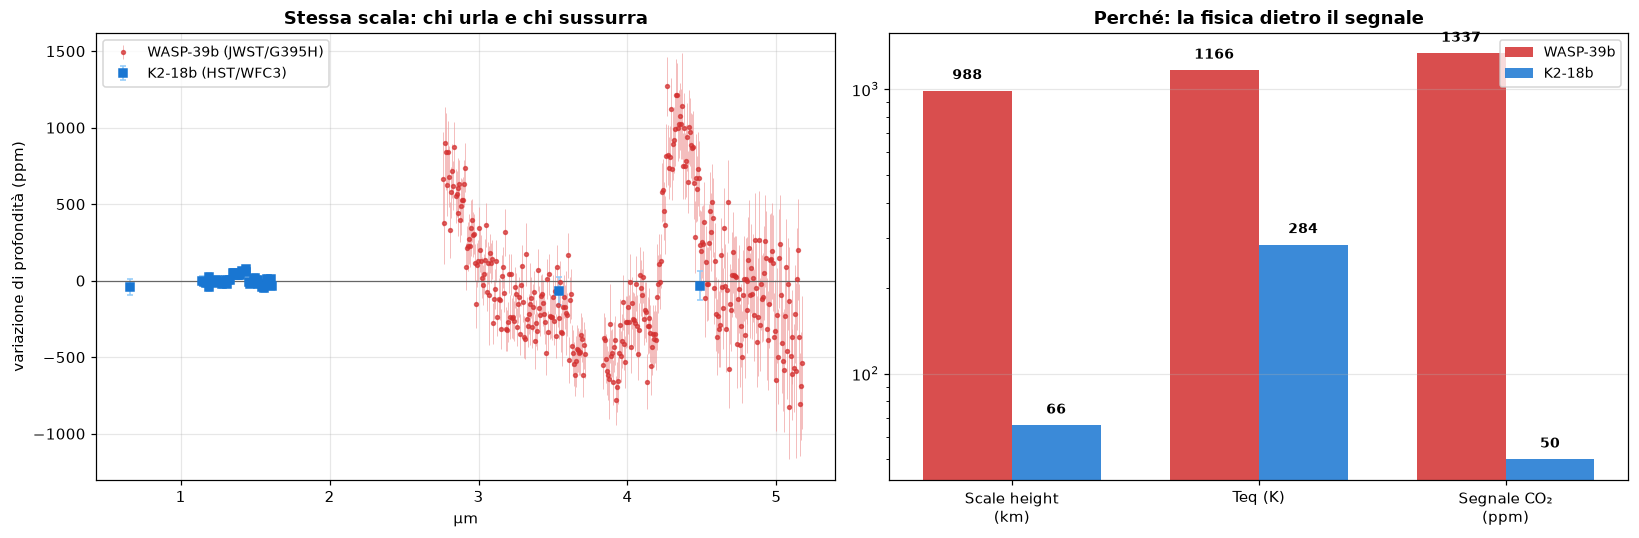

(il valore 50 ppm per K2-18b e' la scala tipica del segnale JWST riportata in
 Madhusudhan et al. 2023: valore di letteratura, non misurato da noi)


In [19]:
# Ampiezza dei due segnali: quanto "spicca" la banda sopra il continuo
amp_w39 = results['CO2']['ppm']
rng_k2 = (dep_k2.max() - dep_k2.min()) * 1e4

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.errorbar(wl, (dep - dep.mean())*1e4, yerr=err*1e4, fmt='o', ms=2.5, color='#D32F2F',
            ecolor='#EF9A9A', lw=0.6, alpha=0.7, label='WASP-39b (JWST/G395H)')
ax.errorbar(wl_k2, (dep_k2 - dep_k2.mean())*1e4, yerr=err_k2*1e4, fmt='s', ms=5,
            color='#1976D2', ecolor='#90CAF9', capsize=2, lw=1, label='K2-18b (HST/WFC3)')
ax.axhline(0, color='0.4', lw=0.8)
ax.set_xlabel('µm'); ax.set_ylabel('variazione di profondità (ppm)')
ax.set_title('Stessa scala: chi urla e chi sussurra', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
g_w, H_w, sig_w = scale_height(params.loc['WASP-39 b'])
g_k, H_k, sig_k = scale_height(params.loc['K2-18 b'])
cat = ['Scale height\n(km)', 'Teq (K)', 'Segnale CO₂\n(ppm)']
w39 = [H_w/1000, params.loc['WASP-39 b','pl_eqt'], amp_w39]
k18 = [H_k/1000, params.loc['K2-18 b','pl_eqt'], 50]
x = np.arange(3); w = 0.36
ax.bar(x - w/2, w39, w, color='#D32F2F', alpha=0.85, label='WASP-39b')
ax.bar(x + w/2, k18, w, color='#1976D2', alpha=0.85, label='K2-18b')
ax.set_yscale('log'); ax.set_xticks(x); ax.set_xticklabels(cat, fontsize=10)
for j, (a, b) in enumerate(zip(w39, k18)):
    ax.text(j - w/2, a*1.1, '%.0f' % a, ha='center', fontsize=9, fontweight='bold')
    ax.text(j + w/2, b*1.1, '%.0f' % b, ha='center', fontsize=9, fontweight='bold')
ax.set_title('Perché: la fisica dietro il segnale', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print('(il valore 50 ppm per K2-18b e\' la scala tipica del segnale JWST riportata in')
print(' Madhusudhan et al. 2023: valore di letteratura, non misurato da noi)')

In [20]:
confronto = pd.DataFrame({
    'WASP-39b': ['Saturno caldo gonfio', 'G8 V (5485 K)', '%.2f R_Jup' % params.loc['WASP-39 b','pl_radj'],
                 '%.3f M_Jup' % params.loc['WASP-39 b','pl_bmassj'], '%.0f K' % params.loc['WASP-39 b','pl_eqt'],
                 '%.1f giorni' % params.loc['WASP-39 b','pl_orbper'], '%.0f km' % (H_w/1000),
                 '%.2f %%' % dep.mean(), '~%.0f ppm' % amp_w39,
                 'JWST/NIRSpec G395H (344 pt)', 'CO₂ %.0fσ, H₂O %.0fσ, SO₂ 4.8σ*' % (results['CO2']['sigma'], results['H2O']['sigma']),
                 '~10x solare', 'analizzati QUI dai dati reali'],
    'K2-18b': ['mini-Nettuno / Hycean', 'M2.5 V (3457 K)', '%.2f R_Jup' % params.loc['K2-18 b','pl_radj'],
               '%.3f M_Jup' % params.loc['K2-18 b','pl_bmassj'], '%.0f K' % params.loc['K2-18 b','pl_eqt'],
               '%.1f giorni' % params.loc['K2-18 b','pl_orbper'], '%.0f km' % (H_k/1000),
               '%.2f %%' % dep_k2.mean(), '~50 ppm (JWST, da paper)',
               'HST/WFC3 (37 pt) — JWST non tabulato', 'CH₄, CO₂ (da paper); DMS controverso',
               'non vincolata bene', 'HST reali + valori da letteratura'],
}, index=['Tipo', 'Stella', 'Raggio', 'Massa', 'Temperatura', 'Periodo', 'Scale height',
          'Profondità transito', 'Segnale atmosferico', 'Dati usati qui', 'Molecole',
          'Metallicità', 'Provenienza'])
print('* SO₂: 4.8σ nel paper; il nostro fit globale lo sottostima (vedi D.4)\n')
display(confronto)

* SO₂: 4.8σ nel paper; il nostro fit globale lo sottostima (vedi D.4)



,WASP-39b,K2-18b
Tipo,Saturno caldo gonfio,mini-Nettuno / Hycean
Stella,G8 V (5485 K),M2.5 V (3457 K)
Raggio,1.28 R_Jup,0.21 R_Jup
Massa,0.281 M_Jup,0.028 M_Jup
Temperatura,1166 K,284 K
Periodo,4.1 giorni,32.9 giorni
Scale height,988 km,66 km
Profondità transito,2.16 %,0.29 %
Segnale atmosferico,~1337 ppm,"~50 ppm (JWST, da paper)"
Dati usati qui,JWST/NIRSpec G395H (344 pt),HST/WFC3 (37 pt) — JWST non tabulato


---
# Conclusioni

## Cosa abbiamo ottenuto

Partendo dallo **spettro JWST/NIRSpec G395H pubblicato**, scaricato dal NASA Exoplanet
Archive, abbiamo riprodotto la prima rilevazione di CO₂ in un'atmosfera esoplanetaria:

| Molecola | Il nostro fit | Alderson et al. 2023 | |
|---|---|---|---|
| **CO₂ 4.3 µm** | **~29σ** | **28.5σ** | ✅ riprodotto |
| **H₂O 2.8 µm** | ~18σ | 21.5σ | ✅ riprodotto |
| **CO 4.6 µm** | ~4σ | ~3–7σ | ✅ coerente |
| **CH₄ 3.3 µm** | 0σ | non rilevato | ✅ controllo superato |
| SO₂ 4.05 µm | 0.8σ globale / **5.6σ locale** | 4.8σ | ⚠️ vedi D.4 |

E abbiamo verificato che i dati fossero autentici *prima* di fidarci: gap dei detector
a 3.713–3.833 µm (paper: 3.717–3.823), R = 604 (paper: ~600), 207 ppm/bin (paper: 221).

## Le tre lezioni di metodo

1. **Un metodo giusto sui dati sbagliati mente senza avvisare** (Parte C). NNLS +
   firme NIST funzionava benissimo nel notebook 015, e qui restituisce CO₂ = 0 — su
   una molecola rilevata a 28.5σ. Non c'era nessun bug: le firme di laboratorio a
   300 K non descrivono un gas a 1166 K. *Il codice non protesta quando l'assunzione
   fisica è sbagliata.*

2. **La scelta del continuo decide il risultato** (Parte D.4). Lo stesso SO₂, sugli
   stessi dati, esce **−138 ppm** con un continuo preso nell'ala dell'H₂O e **+300 ppm
   (5.6σ)** con il continuo corretto. Un riferimento sbagliato può cancellare una
   scoperta vera.

3. **I controlli negativi valgono quanto le rilevazioni.** Il CH₄ a 0σ è ciò che rende
   credibile la CO₂ a 29σ: dimostra che il metodo non fabbrica segnali.

## Cosa chiude, rispetto al notebook 015

Il 015 aveva un compromesso dichiarato: la Parte B era **simulata**, perché per K2-18b
lo spettro JWST non è tabulato (l'abbiamo ri-verificato qui: **zero righe NIRSpec**).
Con WASP-39b quel compromesso sparisce — **ogni numero di questo notebook viene da
fotoni realmente misurati**, e ogni passaggio è confrontabile con Nature.

## Perché WASP-39b urla e K2-18b sussurra

Non è fortuna, è fisica: WASP-39b è **caldo** (1166 K contro 284 K) e ha **gravità
bassa** per la sua taglia (massa di Saturno, raggio di Giove). Le due cose insieme
gonfiano la sua atmosfera fino a una scale height di ~1100 km contro ~200 km, e il
pianeta è grande rispetto alla sua stella. Risultato: ~1000 ppm contro ~50 ppm.

**Il progetto era difficile nel metodo, non nella sensibilità** — esattamente come
previsto.

## Possibili estensioni

- Confrontare le **riduzioni indipendenti** (Eureka!, FIREFLy, Tiberius, tshirt) già
  presenti in `transitspec`: quanto dipende il risultato dal software?
- Aggiungere lo spettro **PRISM** (0.5–5.5 µm, 207 punti) e cercare Na/K nel visibile.
- Scaricare i dati originali da **Zenodo** ([10.5281/zenodo.7185300](https://doi.org/10.5281/zenodo.7185300))
  e confrontarli con la versione dell'archivio.
- Usare **HITRAN/ExoMol** con opacità a 1100 K per un fit fisicamente completo → è la
  strada per recuperare l'SO₂ a 4.8σ come nei paper.